In [3]:
from parsing import list_files
from path_info import CORPUS_PATH

files = list_files(CORPUS_PATH)

In [4]:
from dataclasses import dataclass
import os
@dataclass
class FileInfo:
    ext:str
    _id:str
    size:int

file_info = [FileInfo(f.split(".")[-1], f, os.path.getsize(f"{CORPUS_PATH}/{f}")) for f in files]

In [5]:
print(file_info[0])

FileInfo(ext='mht', _id='00144d5c-5cb7-4267-96a2-5ed556cfb2b8.mht', size=1385196)


- File type distribution​
- File size distribution​
- File size distribution based on file type​
- Parsing time information

In [6]:
from matplotlib import pyplot as plt

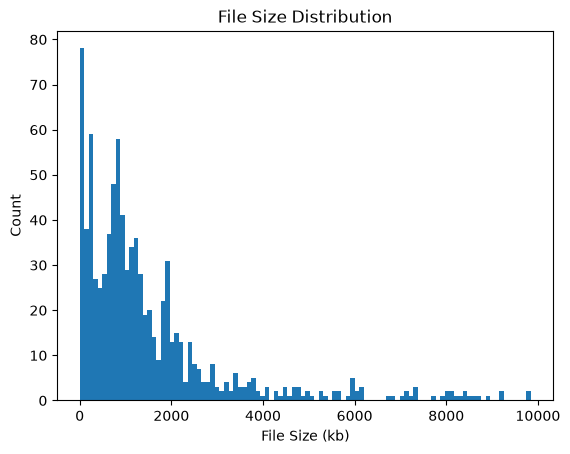

In [7]:
data = []
for f in file_info:
    if f.size < 10e6:
        data.append(f.size/1000)
plt.hist(data, bins=100)
plt.title("File Size Distribution")
plt.xlabel("File Size (kb)")
plt.ylabel("Count")
plt.show()

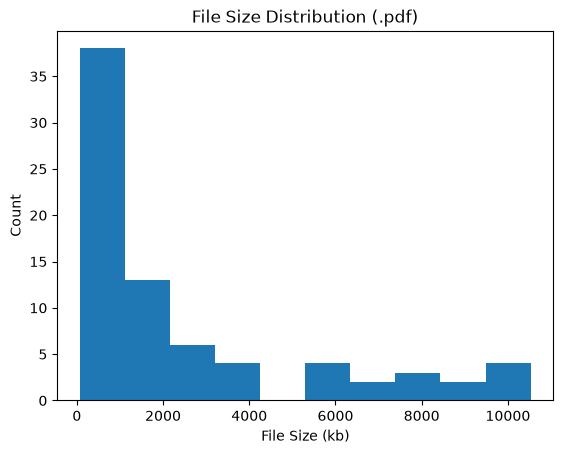

In [8]:
# file size by type distribution:
pdf_data = []
for f in file_info:
    if f.size < 10e6*1.5 and f.ext == "pdf":
        pdf_data.append(f.size/1000)
plt.hist(pdf_data, bins=10)
plt.title("File Size Distribution (.pdf)")
plt.xlabel("File Size (kb)")
plt.ylabel("Count")
plt.show()


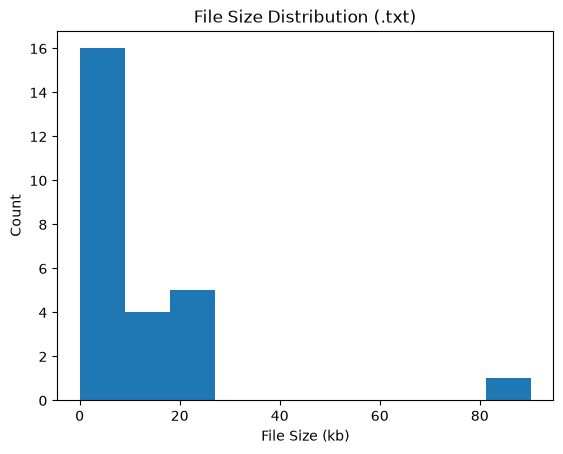

In [9]:
# file size by type distribution:
txt_data = []
for f in file_info:
    if f.ext == "txt":
        txt_data.append(f.size/1000)
plt.hist(txt_data, bins=10)
plt.title("File Size Distribution (.txt)")
plt.xlabel("File Size (kb)")
plt.ylabel("Count")
plt.show()

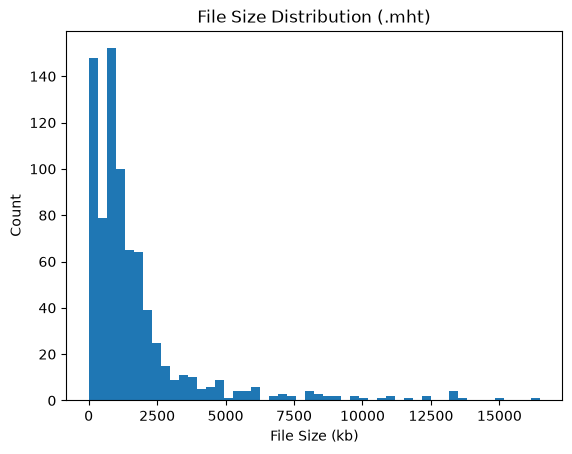

In [10]:
# file size by type distribution:
mht_data = []
for f in file_info:
    if (f.ext == "mht" or f.ext == "mhtml") and f.size < 10e6*1.7:
        mht_data.append(f.size/1000)
plt.hist(mht_data, bins=50)
plt.title("File Size Distribution (.mht)")
plt.xlabel("File Size (kb)")
plt.ylabel("Count")
plt.show()

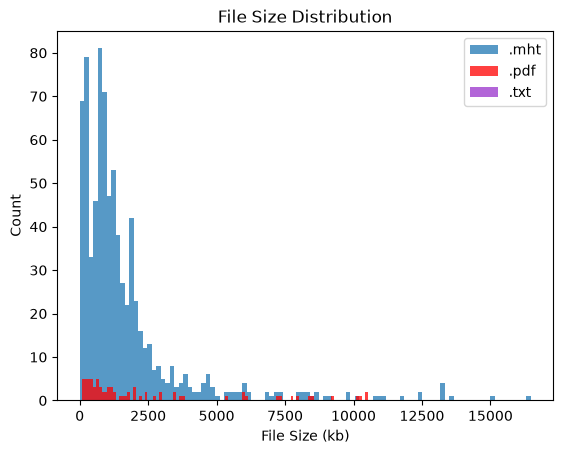

In [11]:
plt.hist(mht_data, label=".mht", bins=100, alpha=0.75)
plt.hist(pdf_data, label=".pdf", bins=100, alpha=0.75, color="red")
plt.hist(txt_data, label=".txt", bins=100, alpha=0.75, color="darkorchid")
plt.legend()
plt.title("File Size Distribution")
plt.xlabel("File Size (kb)")
plt.ylabel("Count")
plt.show()

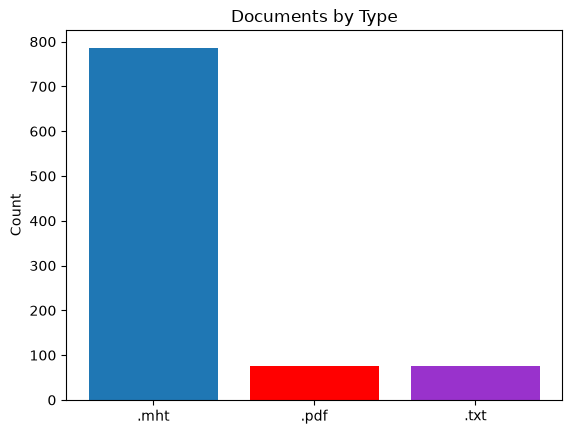

[786, 76, 76]


In [12]:
categories = ['.mht', '.pdf', '.txt']
values = [len(mht_data), len(pdf_data), len(pdf_data)]
colors=['tab:blue', "red", "darkorchid"]
plt.bar(categories, values, color=colors)
plt.title("Documents by Type")
plt.ylabel("Count")
plt.show()
print(values)

In [13]:
def calculate_percentile_size(data_, percentile_) -> int:
    """returns the size at the nth percentile"""
    return data_[round(percentile_*len(data_))].size

print(calculate_percentile_size(file_info, 0.95)/1000, "kb")

1802.372 kb


In [14]:
print(values[0]/len(file_info))

0.8704318936877077
